In [1]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [4]:
docs=(
    PyPDFLoader("../Document/book1.pdf").load()+
    PyPDFLoader("../Document/book2.pdf").load()+
    PyPDFLoader("../Document/book3.pdf").load()
)

In [5]:
splitters=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)

chunks=splitters.split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [6]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [7]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [8]:
retriever=vectorstore.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [25]:
upper_th=0.7
lower_th=0.3

In [42]:
class State(TypedDict):
    que: str
    docs: List[Document]

    good_docs:List[Document]
    verdict:str
    reason:str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

In [56]:
def retrieve(state: State) -> State:
    q = state["que"]
    return {"docs": retriever.invoke(q)}

In [57]:
class DocEvalScore(BaseModel):
    score:float
    reason:str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain=doc_eval_prompt|llm.with_structured_output(DocEvalScore)


In [58]:
def eval_each_doc(state:State)->State:
    q=state['que']
    scores:List[float]=[]
    reasons:List[str]=[]
    good:List[Document]=[]

    for d in state['docs']:
        out=doc_eval_chain.invoke({"question":q,"chunk":d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score>lower_th:
            good.append(d)
    
    if any(s>upper_th for s in scores):
        return{
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {upper_th}.",
        }
    
    if len(scores)>0 and all(s<lower_th for s in scores):
        why="No chunk was sufficient."
        return{
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {lower_th}. {why}",
        }
    
    why="Mixed relevence signals."
    return{
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {upper_th}, but not all were < {lower_th}. {why}",
    }

In [59]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------

def decompose_to_sentence(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentence=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentence if len(s.strip())>20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        (
            "human", "Question: {question}\n\nSentence:\n{sentence}"
        )
    ]
)

filter_chain=filter_prompt|llm.with_structured_output(KeepOrDrop)

In [60]:
def refine(state:State)->State:
    q=state['que']

    context="\n\n".join(d.page_content for d in state["good_docs"]).strip()

    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    redefined_context="\n".join(kept).strip()

    return{
        "strips":strips,
        "kept_strips":kept,
        "refined_context":redefined_context,
    }

In [61]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state:State)->State:
    out=(answer_prompt|llm).invoke({
        "question": state["que"], "refined_context": state['refined_context']
    })
    return {"answer": out.content}

In [62]:
def fail(state:State)->State:
    return{
        "answer":f"FAIL:{state['reason']}"
    }



In [63]:
def ambiguous(state:State)->State:
    return{
        "answer":f"AMBIGIOUS: {state['reason']}"
    }

In [64]:
def route(state:State)->str:
    if state['verdict']=="CORRECT":
        return "refine"
    elif state['verdict']=="INCORRECT":
        return "web_search"
    else:
        return "ambiguous"


In [65]:
graph=StateGraph(State)

graph.add_node("Retrive",retrieve)
graph.add_node("Evaluate",eval_each_doc)

graph.add_node("Ambiguous",ambiguous)
graph.add_node("Fail",fail)
graph.add_node("Refine",refine)
graph.add_node("Generate",generate)

graph.add_edge(START,"Retrive")
graph.add_edge("Retrive","Evaluate")
graph.add_conditional_edges(
    "Evaluate",
    route,
    {
        "refine":"Refine",
        "web_search":"Fail",
        "ambiguous":"Ambiguous",
    }
)
graph.add_edge("Ambiguous",END)
graph.add_edge("Fail",END)
graph.add_edge("Refine","Generate")
graph.add_edge("Generate",END)

In [66]:
app=graph.compile()

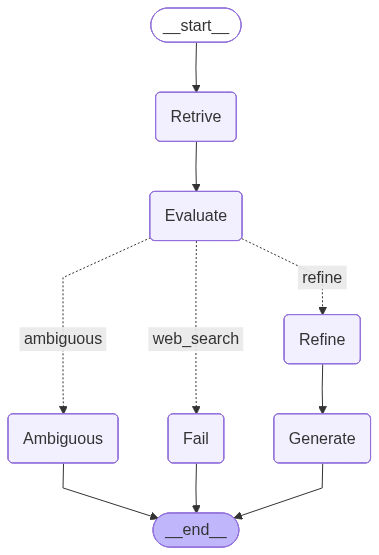

In [67]:
app

In [69]:
res = app.invoke(
    {
        "que": "Bias variance tradeoff",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

OUTPUT:
 The bias‑variance trade‑off describes how the expected error of a model can be decomposed into three parts: the squared bias of the estimator, its variance, and an irreducible noise term.  

- **Bias** measures the expected deviation of the estimator’s average prediction from the true function or parameter value.  
- **Variance** measures how much the estimator’s predictions fluctuate when the training data are resampled (i.e., the deviation from the expected estimator value caused by a particular sampling of the data).  

The mean‑squared error (MSE) of an estimator can be written as  

\[
\text{MSE}= \bigl[\operatorname{Bias}(\hat\theta)\bigr]^2 + \operatorname{Var}(\hat\theta) + \text{noise},
\]

where the bias and variance terms are integrated (or averaged) over the input distribution, as shown in the formulas for integrated squared bias and integrated variance.  

Because bias and variance tend to move i